# Task 3 (LO1, LO2, LO4): Investigate a Quantum Code — Quantum Tic-Tac-Toe

This notebook completes and analyses a partially developed interactive Quantum Tic-Tac-Toe game.  
It:

- completes missing logic (win conditions + gate actions),
- generates quantum circuits through gameplay,
- runs several rounds and shows the generated circuits,
- supports writing a report explaining the code and quantum gates used.

**How to use:** Run all code cells, then play using the buttons.  
Take screenshots of the board + circuit for at least 3 rounds.

In [1]:
!pip -q install qiskit qiskit-aer pylatexenc ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.3 MB/s eta 0:00:00


In [2]:
import math
import numpy as np
from IPython.display import clear_output, display
from ipywidgets import Button, Layout
from google.colab import widgets

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [3]:
class Board:
    """
    Quantum Tic-Tac-Toe board.

    - 9 tiles = 9 qubits
    - Each round starts by resetting all qubits and applying H, preparing |+> on every tile.
    - Moves append gates to the circuit.
    - 'Measure' collapses the entire board (shots=1) into classical X/O results.
    """

    def __init__(self):
        self.qc = QuantumCircuit(9, 9)
        self.function = ""    # selected move: Not, O, X, SWAP
        self.target = -1      # used by SWAP (first selected tile)
        self.tab = []         # stores tile label / history for UI display
        self.winsX = 0
        self.winsO = 0

        # Initialise each tile in |+> = H|0>
        for idx in range(9):
            self.tab.append({"default": str(idx), "player": " "})
            self.qc.reset(idx)
            self.qc.h(idx)

        self.qc.barrier()

    def make_move(self, cell: int):
        """
        Apply the selected move to the chosen cell.
        Note: the displayed board is a move log; the real state is the quantum circuit.
        """
        cell = int(cell)

        if self.function == "Not":
            # X gate flips |0> <-> |1>
            self.qc.x(cell)
            self.tab[cell]["player"] += "N - "

        elif self.function == "O":
            # Bias toward |0>:
            # Tiles begin in |+>. Applying H maps |+> -> |0>.
            self.qc.h(cell)
            self.tab[cell]["player"] += "O - "

        elif self.function == "X":
            # Bias toward |1>:
            # H maps |+> -> |0>, then X maps |0> -> |1>.
            self.qc.h(cell)
            self.qc.x(cell)
            self.tab[cell]["player"] += "X - "

        elif self.function == "SWAP":
            # SWAP requires two tile clicks: first selects, second swaps
            if self.target == -1:
                self.target = cell
                self.tab[cell]["player"] += "S? - "
            else:
                if self.target != cell:
                    self.qc.swap(self.target, cell)
                    self.tab[self.target]["player"] += "S - "
                    self.tab[cell]["player"] += "S - "
                self.target = -1  # reset selection

    def display(self):
        """Display the current circuit."""
        display(self.qc.draw("mpl"))

    def results(self):
        """Show the final circuit for the round, then reset circuit for next round."""
        display(self.qc.draw("mpl"))
        self.qc = QuantumCircuit(9, 9)

    def measure(self):
        """
        Measure all tiles (shots=1) and collapse the board.
        Interpret measurement bits as:
        - 0 -> O
        - 1 -> X
        """
        self.qc.barrier()
        for i in range(9):
            self.qc.measure(i, i)

        simulator = AerSimulator()
        job = simulator.run(self.qc, shots=1)
        counts = job.result().get_counts()
        bitstring = list(counts.keys())[0]

        # Qiskit bitstring order is typically reversed relative to qubit index
        for i in range(9):
            bit = bitstring[9 - 1 - i]
            self.tab[i]["player"] = "O" if bit == "0" else "X"

        self.winsX = self.countWinners("X")
        self.winsO = self.countWinners("O")

    def countWinners(self, player: str) -> int:
        """
        Count completed winning lines for a player.
        Standard 3x3 tic-tac-toe has 8 win conditions.
        """
        winners = (
            (0, 1, 2), (3, 4, 5), (6, 7, 8),  # rows
            (0, 3, 6), (1, 4, 7), (2, 5, 8),  # columns
            (0, 4, 8), (2, 4, 6)              # diagonals
        )

        wins = 0
        for triple in winners:
            if all(self.tab[idx]["player"] == player for idx in triple):
                wins += 1
        return wins

    def new(self):
        """Start a new round (fresh board + fresh circuit)."""
        self.tab.clear()
        self.qc = QuantumCircuit(9, 9)

        for idx in range(9):
            self.tab.append({"default": str(idx), "player": " "})
            self.qc.reset(idx)
            self.qc.h(idx)

        self.qc.barrier()
        self.function = ""
        self.target = -1
        self.winsX = 0
        self.winsO = 0

In [4]:
class Game:
    """
    UI wrapper class.
    Creates buttons for:
    - functions: Measure, Not, O, X, SWAP
    - board cells: 0..8
    """

    def __init__(self):
        self.selecting = False  # used for SWAP: indicates we're waiting for 2nd click
        self.board = Board()

        # Create 9 board buttons
        self.boardbutton_list = []
        for i in range(9):
            btn = Button(description=str(i))
            btn.on_click(self.handle_game)
            self.boardbutton_list.append(btn)

        # Create function buttons
        self.funcbutton_list = []
        self.newButton("Measure")
        self.newButton("Not")
        self.newButton("O")
        self.newButton("X")
        self.newButton("SWAP")

        self.printmenu()
        self.printBoard()
        self.board.display()

    def newButton(self, name):
        btn = Button(description=name, layout=Layout(width="86px", height="30px"))
        btn.on_click(self.handle_game)
        self.funcbutton_list.append(btn)

    def handle_game(self, b):
        """
        Main click handler.
        - Function buttons set the current mode.
        - Cell buttons apply the gate action to the circuit.
        """
        try:
            # If Measure clicked
            if b.description == "Measure":
                clear_output()
                self.replay_button()
                self.board.measure()
                self.scoreboard()
                self.printmenu()
                self.printBoard()
                self.board.results()
                return

            # If Replay clicked
            if b.description == "Replay":
                clear_output()
                self.board.new()
                self.printmenu()
                self.printBoard()
                self.board.display()
                return

            # Otherwise it's a cell click (0..8)
            cell = int(b.description)

            clear_output()
            self.printmenu()
            self.board.make_move(cell)
            self.printBoard()
            self.board.display()

            # SWAP selection handling
            if self.board.function == "SWAP" and self.board.target != -1:
                self.selecting = True
            else:
                self.selecting = False

        except ValueError:
            # It's a function button
            self.board.function = b.description
            self.selecting = False
            if self.board.function == "SWAP":
                self.selecting = True

    def printmenu(self):
        grid = widgets.Grid(1, 5)
        for (row, col) in grid:
            display(self.funcbutton_list[col])

    def scoreboard(self):
        print("X wins:", self.board.winsX, "    O wins:", self.board.winsO)

    def replay_button(self):
        rep = Button(description="Replay")
        rep.on_click(self.handle_game)
        display(rep)

    def printBoard(self):
        grid = widgets.Grid(1, int(np.sqrt(9)), header_row=True, header_column=True)
        for row in range(int(np.sqrt(9))):
            for (_, col) in grid:
                idx = col + row * int(np.sqrt(9))
                print("\n" + self.board.tab[idx]["player"] + "\n")
                display(self.boardbutton_list[idx])

Button(description='Replay', style=ButtonStyle())

X wins: 0     O wins: 5


,,,,


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


O



Button(description='8', style=ButtonStyle())

<IPython.core.display.Javascript object>

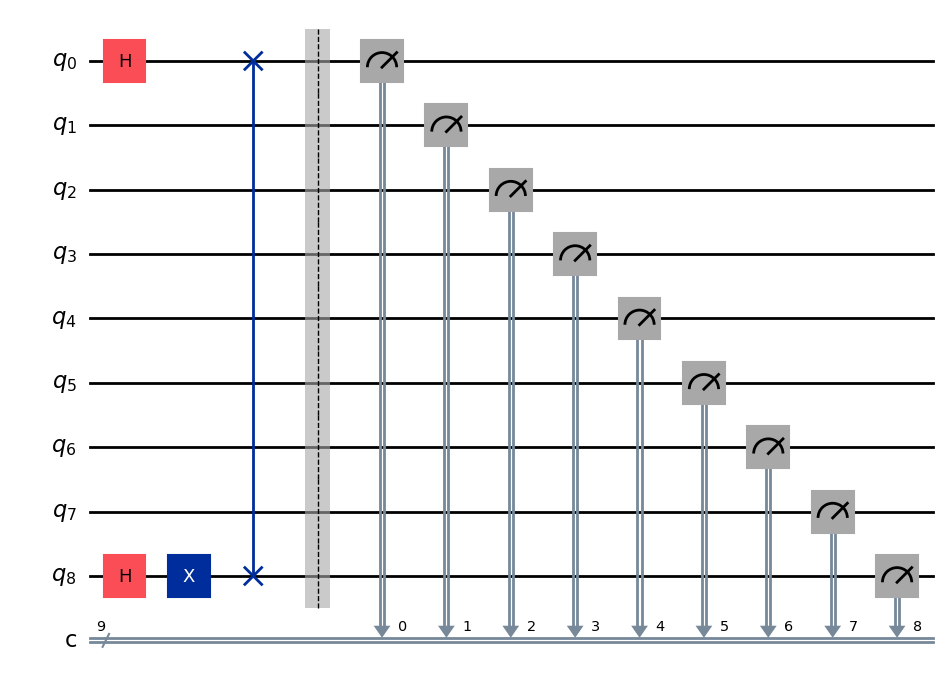

In [6]:
game = Game()